<a href="https://colab.research.google.com/github/nds-najam/Chronos_Model_Comparison/blob/main/TimesFM_2_5_LTSM_ETTh1_CustomModelAutoGluon_localPath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TimesFM 2.5 as a custom AutoGluon TimeSeries model (Colab GPU)

AutoGluon's `autogluon.timeseries` already ships pretrained foundation-model wrappers for **Chronos-Bolt**, **Chronos-T5**, and **Chronos-2**. This notebook adds **Google's TimesFM 2.5** (200M params) by subclassing `autogluon.timeseries.models.abstract.AbstractTimeSeriesModel` -- the same extension point AutoGluon itself uses for Chronos/Toto -- so it can be trained, benchmarked, and predicted with through the normal `TimeSeriesPredictor` API.

It benchmarks the custom `TimesFM25Model` against AutoGluon's built-in **Chronos-2** and **Chronos-T5-small** on **ETTh1**.

**Before running:** `Runtime -> Change runtime type -> T4 GPU` (or better). `Chronos-T5-small` specifically requires a GPU -- AutoGluon raises a `RuntimeError` for it on CPU-only runtimes (`chronos-t5-mini` and all `chronos-bolt-*` variants are the CPU-safe ones, if you ever need to fall back).

**Checkpoints.** Everything below downloads automatically from the Hugging Face Hub on first use (TimesFM 2.5, Chronos-2, Chronos-T5) -- no setup needed. If you'd rather use the checkpoints already saved in your Google Drive `Checkpoints` folder (avoids a ~900MB re-download each fresh Colab session), mount Drive and point `TIMESFM_MODEL_PATH` at the local folder -- see the commented-out cell below.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q "autogluon.timeseries==1.6.1" "timesfm[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0/864.0 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
import sys
from importlib.metadata import PackageNotFoundError, version

import torch


def get_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"


print("Python              :", sys.version.split()[0])
print("PyTorch             :", get_version("torch"))
print("AutoGluon TimeSeries:", get_version("autogluon.timeseries"))
print("TimesFM             :", get_version("timesfm"))
print("CUDA available      :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU                 :", torch.cuda.get_device_name(0))

TIMESFM_MODEL_PATH = "/content/drive/MyDrive/15_ARAMCO/Checkpoints/timesfm-2.5-200m-pytorch"  # downloads from the HF Hub on first use

Python              : 3.13.15
PyTorch             : 2.11.0+cu128
AutoGluon TimeSeries: 1.6.1
TimesFM             : 2.0.2
CUDA available      : True
GPU                 : Tesla T4


Optional: use the checkpoint from your Google Drive `Checkpoints` folder instead of re-downloading from the Hub. Uncomment and run this cell (after mounting Drive and confirming the exact subfolder path -- share settings mean it may show up under "Shared with me" rather than "My Drive" unless you've added a shortcut) before the model-definition cell below.

In [4]:
# from google.colab import drive
# drive.mount("/content/drive")
# TIMESFM_MODEL_PATH = "/content/drive/MyDrive/Checkpoints/timesfm-2.5-200m-pytorch"
# print("Using local checkpoint:", TIMESFM_MODEL_PATH)

## Custom AutoGluon model: `TimesFM25Model`

Zero-shot / inference-only wrapper: `_fit` just loads + compiles the pretrained checkpoint, no gradient training happens on `train_data`.

Two issues surfaced while getting this class to actually run, both fixed here:

- **Pickling crash.** AutoGluon calls `model.save()` (pickle) right after fitting. The compiled TimesFM object holds a closure created inside `compile()` (`_compiled_decode`), which Python's pickler can't serialize -- it fails with `AttributeError: Can't pickle local object 'TimesFM_2p5_200M_torch.compile.<locals>._compiled_decode'`. The fix (the same pattern AutoGluon's own `TotoModel` uses): drop `self._model` before calling `super().save()`, restore it after, and lazily reload it in `_predict` if needed.
- **Quantile columns.** `model.forecast()` returns a `(n_items, horizon, 10)` quantile tensor. Empirically (verified against a live forecast call -- checked that values are monotonically increasing across the columns), column 0 is an unfixed/unused spare slot, and columns 1-9 are the 9 quantiles `[0.1 .. 0.9]` in order, with column 5 doubling as the dedicated point/AR forecast in place of a separate 0.5 head.

`torch_compile` defaults to on when a GPU is present (Triton generally works fine on Colab) and off on CPU (Triton is frequently unavailable there).

In [5]:
import numpy as np
import pandas as pd

from autogluon.timeseries import TimeSeriesDataFrame
from autogluon.timeseries.models.abstract import AbstractTimeSeriesModel


class TimesFM25Model(AbstractTimeSeriesModel):
    """AutoGluon-compatible wrapper around TimesFM 2.5 (google/timesfm-2.5-200m-pytorch)."""

    default_model_path = "google/timesfm-2.5-200m-pytorch"
    _native_quantile_levels = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
    _native_start_index = 1  # native quantile tensor column 0 is unused, see note above

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._model = None

    def _get_default_hyperparameters(self):
        return {
            "model_path": self.default_model_path,
            "context_length": 512,
            "torch_compile": torch.cuda.is_available(),
            "use_continuous_quantile_head": True,
            "fix_quantile_crossing": True,
        }

    @property
    def allowed_hyperparameters(self):
        return super().allowed_hyperparameters + [
            "model_path",
            "context_length",
            "torch_compile",
            "use_continuous_quantile_head",
            "fix_quantile_crossing",
        ]

    def load_model(self):
        import timesfm

        params = self.get_hyperparameters()
        model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
            params["model_path"],
            torch_compile=params["torch_compile"],
        )
        # compile() rounds max_context / max_horizon up to multiples of the model's patch
        # sizes (32 / 128) itself, logging when it does so.
        model.compile(
            timesfm.ForecastConfig(
                max_context=params["context_length"],
                max_horizon=max(self.prediction_length, 128),
                normalize_inputs=True,
                use_continuous_quantile_head=params["use_continuous_quantile_head"],
                fix_quantile_crossing=params["fix_quantile_crossing"],
            )
        )
        self._model = model

    def persist(self):
        if self._model is None:
            self.load_model()
        return self

    def save(self, path=None, verbose=True):
        model = self._model
        self._model = None
        try:
            saved_path = super().save(path=path, verbose=verbose)
        finally:
            self._model = model
        return saved_path

    def _fit(self, train_data, val_data=None, time_limit=None, **kwargs):
        self._check_fit_params()
        self.load_model()

    def _predict(self, data, known_covariates=None, **kwargs):
        if self._model is None:
            self.load_model()

        context_length = self.get_hyperparameters()["context_length"]
        inputs = []
        for item_id in data.item_ids:
            series = data.loc[item_id][self.target].to_numpy(dtype=np.float64)
            series = series[~np.isnan(series)][-context_length:]
            if len(series) == 0:
                series = np.zeros(1, dtype=np.float64)
            inputs.append(series)

        point_forecast, quantile_forecast = self._model.forecast(
            horizon=self.prediction_length, inputs=inputs
        )
        native_quantiles = quantile_forecast[..., self._native_start_index:]

        columns = {"mean": point_forecast.reshape(-1)}
        for level in self.quantile_levels:
            if level in self._native_quantile_levels:
                idx = self._native_quantile_levels.index(level)
                values = native_quantiles[..., idx]
            else:
                values = np.apply_along_axis(
                    lambda q: np.interp(level, self._native_quantile_levels, q), -1, native_quantiles
                )
            columns[str(level)] = values.reshape(-1)

        result = pd.DataFrame(columns, index=self.get_forecast_horizon_index(data))
        return TimeSeriesDataFrame(result)


print("TimesFM25Model defined:", TimesFM25Model)

TimesFM25Model defined: <class '__main__.TimesFM25Model'>


## Load ETTh1 and build the AutoGluon dataset

A single univariate series on the `OT` (oil temperature) column, item id `ETTh1_OT`.

In [6]:
DATA_URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
TARGET = "OT"

df = pd.read_csv(DATA_URL)
df["date"] = pd.to_datetime(df["date"])

ag_df = df[["date", TARGET]].copy()
ag_df["item_id"] = "ETTh1_OT"
ag_df = ag_df[["item_id", "date", TARGET]]

full_data = TimeSeriesDataFrame.from_data_frame(ag_df, id_column="item_id", timestamp_column="date")
print("full_data:", full_data.shape)
full_data.tail()

full_data: (17420, 1)


OT
item_id  timestamp                  
ETTh1_OT 2018-06-26 15:00:00  10.904
         2018-06-26 16:00:00  11.044
         2018-06-26 17:00:00  10.271
         2018-06-26 18:00:00   9.778
         2018-06-26 19:00:00   9.567

In [7]:
PREDICTION_LENGTH = 48
CONTEXT_LENGTH = 512

# test_data holds out the final PREDICTION_LENGTH hours as ground truth for the leaderboard.
# tuning_data holds out one more window before that, used by AutoGluon to compute val_score
# during fit. Passing tuning_data explicitly (instead of letting AutoGluon carve its own
# validation window out of train_data) avoids wrapping each model in a
# MultiWindowBacktestingModel, which would otherwise load + compile every pretrained model
# twice.
train_data, test_data = full_data.train_test_split(prediction_length=PREDICTION_LENGTH)
train_data, tuning_data = train_data.train_test_split(prediction_length=PREDICTION_LENGTH)

print("train_data  :", train_data.shape)
print("tuning_data :", tuning_data.shape)
print("test_data   :", test_data.shape)

train_data  : (17324, 1)
tuning_data : (17372, 1)
test_data   : (17420, 1)


## Benchmark: TimesFM 2.5 vs Chronos-2 vs Chronos-T5-small

Three zero-shot models, trained (loaded) and evaluated on identical data. `enable_ensemble=False` so the leaderboard reports each model's own score rather than an ensemble.

In [13]:
from autogluon.timeseries import TimeSeriesPredictor

benchmark_predictor = TimeSeriesPredictor(
    prediction_length=PREDICTION_LENGTH,
    target=TARGET,
    eval_metric="MASE",
    # path="AutogluonModels/etth1_timesfm25_chronos_benchmark",
    path="/content/drive/MyDrive/15_ARAMCO/Checkpoints/etth1_timesfm25_chronos_benchmark",
)

benchmark_predictor.fit(
    train_data=train_data,
    tuning_data=tuning_data,
    hyperparameters={
        # 1. Our custom TimesFM 2.5
        TimesFM25Model: {
            "context_length": CONTEXT_LENGTH,
            "model_path": TIMESFM_MODEL_PATH,
        },
        # 2. Chronos-2 (ETTh1 has only one series here, so cross-learning has nothing to learn from)
        "Chronos2": {
            # "model_path": "autogluon/chronos-2",
            "model_path": "/content/drive/MyDrive/15_ARAMCO/Checkpoints/autogluon_checkpoints/chronos-2",
            "cross_learning": False,
        },
        # 3. Original Chronos-T5 (small) -- needs a GPU, which is why this notebook targets Colab
        "Chronos": {
            # "model_path": "autogluon/chronos-t5-small",
            "model_path": "/content/drive/MyDrive/15_ARAMCO/Checkpoints/autogluon_checkpoints/chronos-t5-small",
        },
    },
    enable_ensemble=False,
    random_seed=123,
    verbosity=2,
)

Beginning AutoGluon training...
AutoGluon will save models to '/content/drive/MyDrive/15_ARAMCO/Checkpoints/etth1_timesfm25_chronos_benchmark'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 13.69/14.56 GB
Total GPU Memory:   Free: 13.69 GB, Allocated: 0.87 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.76 GB / 12.67 GB (77.0%)
Disk Space Avail:   26.94 GB / 100.00 GB (26.9%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {<class '__main__.TimesFM25Model'>: {'context_length': 512,
                                                         'model_path': '/content/drive/MyDrive/15_ARAMCO/Checkpoints/timesfm-2.5-200m-pytorch'},
                     'Chronos':

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-0.2007       = Validation score (-MASE)
	1.09    s     = Training runtime
	0.11    s     = Validation (prediction) runtime
Training timeseries model Chronos[eckpoints__autogluon_checkpoints__chronos-t5-small]. 


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

	-0.3561       = Validation score (-MASE)
	0.01    s     = Training runtime
	0.98    s     = Validation (prediction) runtime
Training timeseries model TimesFM25. 
	-0.3541       = Validation score (-MASE)
	2.85    s     = Training runtime
	0.11    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2', 'Chronos[eckpoints__autogluon_checkpoints__chronos-t5-small]', 'TimesFM25']
Total runtime: 8.30 s
Best model: Chronos2
Best model score: -0.2007


In [14]:
leaderboard = benchmark_predictor.leaderboard(test_data, silent=False)
leaderboard

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

                                               model  score_test  score_val  pred_time_test  pred_time_val  fit_time_marginal  fit_order
0  Chronos[eckpoints__autogluon_checkpoints__chro...   -0.385982  -0.356096        0.954312       0.979969           0.010708          2
1                                          TimesFM25   -0.403632  -0.354095        3.560728       0.112726           2.848660          3
2                                           Chronos2   -0.418048  -0.200714        1.119828       0.106499           1.087726          1


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos[eckpoints__autogluon_checkpoints__chro...,-0.385982,-0.356096,0.954312,0.979969,0.010708,2
1,TimesFM25,-0.403632,-0.354095,3.560728,0.112726,2.848660,3
2,Chronos2,-0.418048,-0.200714,1.119828,0.106499,1.087726,1


## Forecast comparison plot

Forecasts are generated from `tuning_data` (history up to, but not including, the final `PREDICTION_LENGTH` hours) and overlaid against the true held-out values from `test_data` -- the same window `test_data` scored the leaderboard on.

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

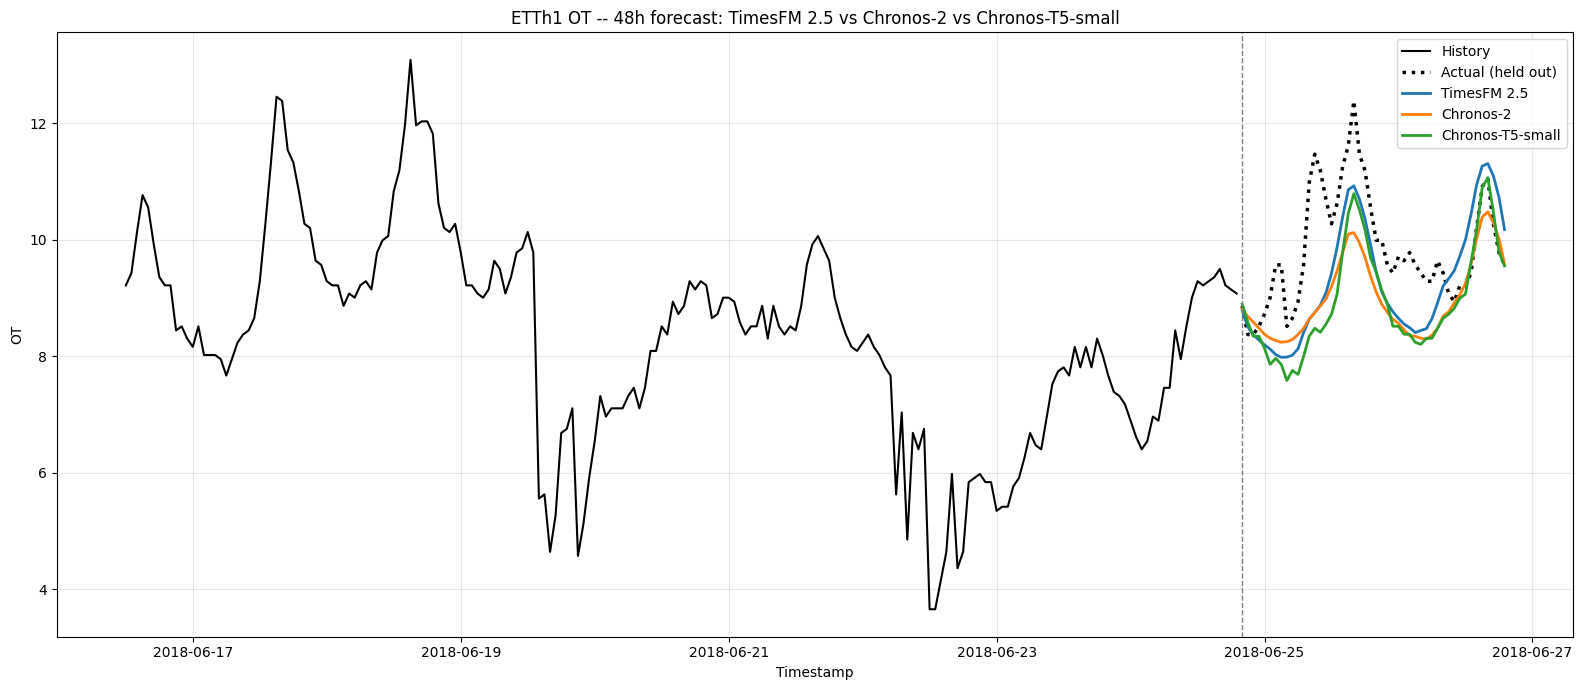

In [16]:
import matplotlib.pyplot as plt

MODEL_NAMES = {
    "TimesFM 2.5": "TimesFM25",
    "Chronos-2": "Chronos2",
    "Chronos-T5-small": "Chronos[eckpoints__autogluon_checkpoints__chronos-t5-small]",
}
ITEM_ID = "ETTh1_OT"
HISTORY_LENGTH = 200

forecasts = {label: benchmark_predictor.predict(tuning_data, model=name) for label, name in MODEL_NAMES.items()}

history = tuning_data.loc[ITEM_ID][TARGET].tail(HISTORY_LENGTH)
actual_future = test_data.loc[ITEM_ID][TARGET].tail(PREDICTION_LENGTH)

plt.figure(figsize=(16, 7))
plt.plot(history.index, history.to_numpy(), label="History", color="black", linewidth=1.5)
plt.plot(actual_future.index, actual_future.to_numpy(), label="Actual (held out)", color="black",
         linewidth=2.5, linestyle=":")

for label in MODEL_NAMES:
    forecast = forecasts[label].loc[ITEM_ID]["mean"]
    plt.plot(forecast.index, forecast.to_numpy(), label=label, linewidth=2)

plt.axvline(actual_future.index[0], color="gray", linestyle="--", linewidth=1)
plt.title("ETTh1 OT -- 48h forecast: TimesFM 2.5 vs Chronos-2 vs Chronos-T5-small")
plt.xlabel("Timestamp")
plt.ylabel("OT")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

`TimesFM25Model` fits, predicts, saves, and reloads correctly alongside AutoGluon's built-in Chronos-2 and Chronos-T5-small on ETTh1 -- see the leaderboard above for the head-to-head MASE/WQL comparison.

**Next steps** (per the original roadmap): apply the same `AbstractTimeSeriesModel` pattern to bring in **MoirAI** and **Toto2** (checkpoints for both are in the shared `Checkpoints` Google Drive folder), then re-run this same benchmark with all five models -- Chronos-2, Chronos-T5, Chronos-Bolt, TimesFM 2.5, MoirAI, Toto2 -- side by side.

### Demonstrating Chronos2 with Cross-Learning and Covariates

To effectively use cross-learning, the model needs additional features (covariates). Here, we'll recreate the dataset to include all original columns from `df` (excluding `date`) as covariates, and then train a `TimeSeriesPredictor` with `Chronos2` and `cross_learning=True`.

In [17]:
# Prepare data with covariates
# Exclude 'date' and 'OT' (target) to use other columns as known covariates
covariate_cols = [col for col in df.columns if col not in ['date', TARGET]]

ag_df_with_covariates = df[['date', TARGET] + covariate_cols].copy()
ag_df_with_covariates["item_id"] = "ETTh1_OT"
ag_df_with_covariates = ag_df_with_covariates[["item_id", "date", TARGET] + covariate_cols]

full_data_with_covariates = TimeSeriesDataFrame.from_data_frame(
    ag_df_with_covariates, id_column="item_id", timestamp_column="date"
)
print("full_data_with_covariates:", full_data_with_covariates.shape)
print("Covariates used:", covariate_cols)

# Split data with covariates
train_data_cov, test_data_cov = full_data_with_covariates.train_test_split(
    prediction_length=PREDICTION_LENGTH
)
train_data_cov, tuning_data_cov = train_data_cov.train_test_split(
    prediction_length=PREDICTION_LENGTH
)

print("train_data_cov  :", train_data_cov.shape)
print("tuning_data_cov :", tuning_data_cov.shape)
print("test_data_cov   :", test_data_cov.shape)

full_data_with_covariates: (17420, 7)
Covariates used: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']
train_data_cov  : (17324, 7)
tuning_data_cov : (17372, 7)
test_data_cov   : (17420, 7)


In [18]:
# Initialize a new predictor with known_covariates_names
chronos2_cross_learning_with_cov_predictor = TimeSeriesPredictor(
    prediction_length=PREDICTION_LENGTH,
    target=TARGET,
    eval_metric="MASE",
    known_covariates_names=covariate_cols, # Specify covariates here
    path="AutogluonModels/etth1_chronos2_cross_learning_with_cov",
)

chronos2_cross_learning_with_cov_predictor.fit(
    train_data=train_data_cov,
    tuning_data=tuning_data_cov,
    hyperparameters={
        "Chronos2": {
            "model_path": "/content/drive/MyDrive/15_ARAMCO/Checkpoints/autogluon_checkpoints/chronos-2",
            "cross_learning": True, # Keep cross_learning enabled
        },
    },
    enable_ensemble=False,
    random_seed=123,
    verbosity=2,
)

print("Leaderboard for Chronos2 with cross-learning and covariates:")
chronos2_cross_learning_with_cov_predictor.leaderboard(test_data_cov, silent=True)

Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/etth1_chronos2_cross_learning_with_cov'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 12.83/14.56 GB
Total GPU Memory:   Free: 12.83 GB, Allocated: 1.73 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       8.96 GB / 12.67 GB (70.7%)
Disk Space Avail:   185.89 GB / 235.68 GB (78.9%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos2': {'cross_learning': True,
                                  'model_path': '/content/drive/MyDrive/15_ARAMCO/Checkpoints/autogluon_checkpoints/chronos-2'}},
 'known_covariates_names': ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL'],
 'num

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-0.3896       = Validation score (-MASE)
	0.91    s     = Training runtime
	0.39    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2']
Total runtime: 1.33 s
Best model: Chronos2
Best model score: -0.3896
Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Leaderboard for Chronos2 with cross-learning and covariates:


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2,-0.382972,-0.389638,1.286932,0.388692,0.905372,1


### Forecast Comparison with Chronos2 Cross-Learning

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

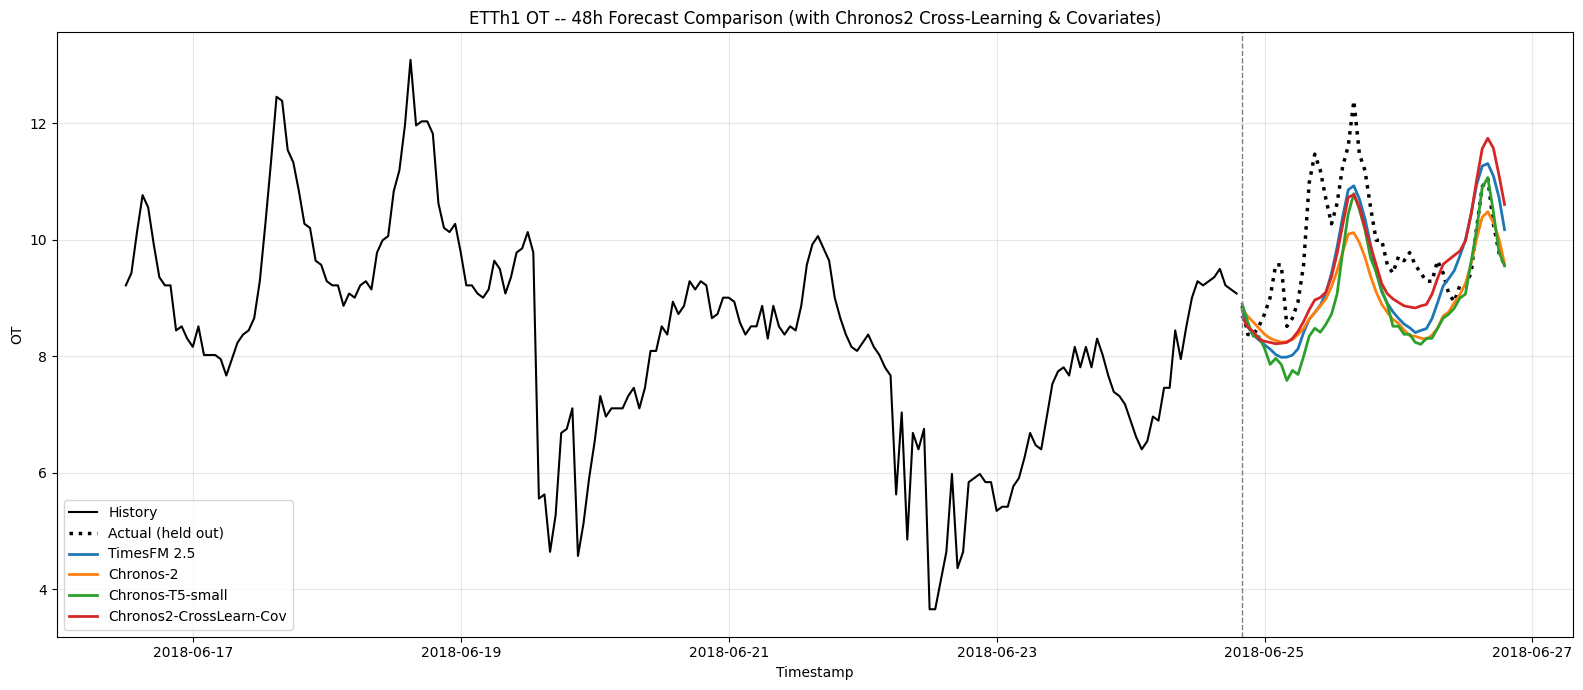

In [23]:
import matplotlib.pyplot as plt

# Extend the MODEL_NAMES dictionary to include the cross-learning Chronos2
MODEL_NAMES_EXTENDED = {
    "TimesFM 2.5": "TimesFM25",
    "Chronos-2": "Chronos2",
    "Chronos-T5-small": "Chronos[eckpoints__autogluon_checkpoints__chronos-t5-small]",
    "Chronos2-CrossLearn-Cov": "Chronos2-CrossLearn-Cov", # A new label for the plot
}

# Re-generate forecasts for existing models using benchmark_predictor
forecasts_extended = {label: benchmark_predictor.predict(tuning_data, model=name) for label, name in MODEL_NAMES_EXTENDED.items() if label != "Chronos2-CrossLearn-Cov"}

# Generate forecast for the new Chronos2 with cross-learning and covariates
# Create the future index blueprint using the predictor's method
future_known_covariates_index_df = chronos2_cross_learning_with_cov_predictor.make_future_data_frame(tuning_data_cov)

# Create a MultiIndex from the item_id and timestamp columns of the future_known_covariates_index_df
# This MultiIndex will be used to correctly select the future covariates from full_data_with_covariates.
future_multi_index = pd.MultiIndex.from_frame(future_known_covariates_index_df[['item_id', 'timestamp']])

# Extract the actual covariate values for the forecast horizon from the full_data_with_covariates
# This ensures perfect alignment with the expected future timestamps and item_ids.
known_covariates_for_prediction = full_data_with_covariates.loc[future_multi_index, covariate_cols]

forecasts_extended["Chronos2-CrossLearn-Cov"] = chronos2_cross_learning_with_cov_predictor.predict(
    tuning_data_cov,
    model='Chronos2',
    known_covariates=known_covariates_for_prediction
)

# Reuse history and actual_future from the original data split for consistent comparison
history = tuning_data.loc[ITEM_ID][TARGET].tail(HISTORY_LENGTH)
actual_future = test_data.loc[ITEM_ID][TARGET].tail(PREDICTION_LENGTH)

plt.figure(figsize=(16, 7))
plt.plot(history.index, history.to_numpy(), label="History", color="black", linewidth=1.5)
plt.plot(actual_future.index, actual_future.to_numpy(), label="Actual (held out)", color="black",
         linewidth=2.5, linestyle=":")

for label in MODEL_NAMES_EXTENDED:
    forecast_data = forecasts_extended[label].loc[ITEM_ID]["mean"]
    plt.plot(forecast_data.index, forecast_data.to_numpy(), label=label, linewidth=2)

plt.axvline(actual_future.index[0], color="gray", linestyle="--", linewidth=1)
plt.title("ETTh1 OT -- 48h Forecast Comparison (with Chronos2 Cross-Learning & Covariates)")
plt.xlabel("Timestamp")
plt.ylabel("OT")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()